# DATA620 Project 1
## Cameron Gray

Movies are a very approachable way to view networks, especially degrees of separation, as shown by [The Oracle of Bacon](https://oracleofbacon.org/). This takes a concept that is normally limited to people who study this stuff, like we are now. The movie industry is also easy to think of as a social network because it kind of is one. Each actor that works on a movie together now has a connection which can be treated as an edge in the network. I am using IMDb data from [Kaggle](https://www.kaggle.com/datasets/rounakbanik/the-movies-dataset?resource=download&select=credits.csv) because unfortunately the API I was planning on using was difficult to gain access to (similar to the discussion post just had). 

First I import all the relevant packages. `pandas` is for the relevant data clean up and analysis. `networkx` is obviously for the network aspects of the project. `numpy` is used for some specific functions.

In [1]:
import pandas as pd
import networkx as nx
import numpy as np
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt

The data is read into a `pandas` dataframe for ease of data manipulation.

In [2]:
cast = pd.read_csv('movie_credits.csv')

Then interating over each movie through the data set and assigning them with the unique movie id and the gender of the actor for each movie. The genders for the actors are then labeled and any unknowns are removed from the dataset. If they aren't labeled it would be a lot of effort to find the genders of the actors and the number of non-binary actors are so small that they aren't a meaningful enough same size to justify keeping them in for this analysis.

In [3]:
df_list = []

for i in range(len(cast['cast'])):
    lst = eval(cast['cast'][i])
    
    actors = [ea.get('name') for ea in lst if 'name' in ea]
    gender = [ea.get('gender') for ea in lst if 'gender' in ea]
    ids = cast['id'][i]*len(lst)
    
    new = pd.DataFrame({'id':ids, 'actor':actors, 'gender':gender})
    df_list.append(new)

df = pd.concat(df_list, ignore_index=True)

df.loc[df['gender'] == 2.0, 'gender'] = 'Male'
df.loc[df['gender'] == 1.0, 'gender'] = 'Female'
df.loc[df['gender'] == 0.0, 'gender'] = 'Unknown'
df = df[df['gender'] != 'Unknown']

print(df)
print(len(df['actor'].unique()))

             id              actor  gender
0         11206          Tom Hanks    Male
1         11206          Tim Allen    Male
2         11206        Don Rickles    Male
3         11206         Jim Varney    Male
4         11206      Wallace Shawn    Male
...         ...                ...     ...
562467  1016370       Peter Dobson    Male
562469  1137530   Iwan Mosschuchin    Male
562470  1137530  Nathalie Lissenko  Female
562471  1137530       Pavel Pavlov    Male
562473  1137530        Vera Orlova  Female

[338510 rows x 3 columns]
63555


C:\Users\norem\AppData\Local\Temp\ipykernel_3056\1353830749.py:15: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'Male' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[df['gender'] == 2.0, 'gender'] = 'Male'


Then the `pandas` dataframe with the actors is merged with itself on the movie id which creates an edgelist to easily feed into the network.

In [4]:
df1 = pd.merge(df,df, on='id')

df1 = df1[['actor_x','actor_y']][df1['actor_x']!=df1['actor_y']]
print(df1)

              actor_x            actor_y
1           Tom Hanks          Tim Allen
2           Tom Hanks        Don Rickles
3           Tom Hanks         Jim Varney
4           Tom Hanks      Wallace Shawn
5           Tom Hanks  John Ratzenberger
...               ...                ...
5243443  Pavel Pavlov  Nathalie Lissenko
5243445  Pavel Pavlov        Vera Orlova
5243446   Vera Orlova   Iwan Mosschuchin
5243447   Vera Orlova  Nathalie Lissenko
5243448   Vera Orlova       Pavel Pavlov

[4903238 rows x 2 columns]


The `networkx` graph object is then created from the the edgelist from above. Which was too big to visualize here so I used Gephi to create a basic visualization which you can see very strong clustering.

In [5]:
G = nx.from_pandas_edgelist(df1, source = 'actor_x', target = 'actor_y')

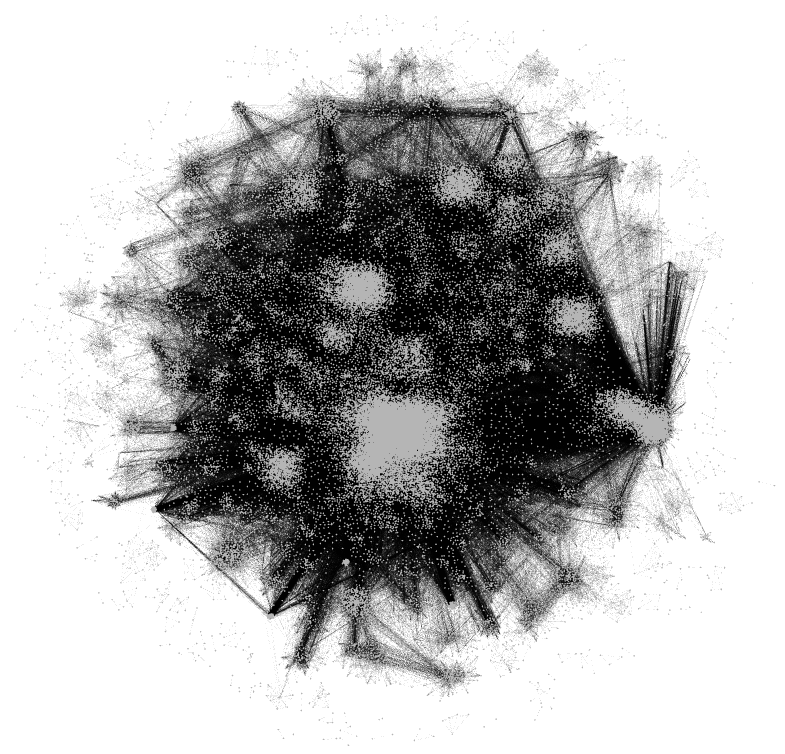

The two centrality measures, degree centrality and the eigenvector centrality, were calculated and attributed to the relevant nodes in the network. The genders of the actors are also grouped and put into a form so they can be set as attributes to the relevant nodes.

In [6]:
dc = nx.degree_centrality(G)
nx.set_node_attributes(G, dc, 'degree')

ec = nx.eigenvector_centrality(G)
nx.set_node_attributes(G, ec, 'eigenvector')

genders = df[['actor','gender']].groupby(['actor'], as_index = False).min().set_index('actor')['gender'].to_dict()
nx.set_node_attributes(G, genders, 'gender')

In [7]:
df1.to_csv("edge_list.csv", index=False)

The centrality measures and gender were then retrieved by the nodes and put into a seperate dataframe for the analysis. It was possible to create this data set without putting the data back into the network but I wanted to display a way to do so if it is easier to attribute the nodes in the network and do the analysis that way. 

In [8]:
lst_centrality = [
    nx.get_node_attributes(G, 'degree'), 
    nx.get_node_attributes(G, 'eigenvector'), 
    nx.get_node_attributes(G, 'gender')
]
centrality = pd.DataFrame(lst_centrality).T
centrality.columns = ['degree', 'eigenvector', 'gender']

After running a groupby with the genders as the the key and running summary statistics on the different centrality measures. A preliminary viewing of the chart of summary statistics doesn't not much of a different between the two groups but you can clearly see that the average measures favor the men but the max values favor the women.

In [9]:
centrality.groupby('gender').agg(['min','max','mean','median','count'])

degree                                      eigenvector            \
             min       max      mean    median  count         min       max   
gender                                                                        
Female  0.000016  0.033635   0.00095  0.000523  25504         0.0  0.098665   
Male    0.000016   0.03018  0.001267  0.000571  37586         0.0  0.077064   

                                   
            mean    median  count  
gender                             
Female  0.000709  0.000121  25504  
Male    0.001235  0.000146  37586

Running T-tests for both centrality measures it is very obvious that there is a statistical difference between the means of the two groups, and one that favors the men with a p-value to fully rejects the null hypothesis (which can likely be attributed to the large sample size.)

In [10]:
stats.ttest_ind(list(centrality[centrality['gender']=='Female']['degree']),
                list(centrality[centrality['gender']=='Male']['degree']))

TtestResult(statistic=-22.021314767314216, pvalue=4.565687795871216e-107, df=63088.0)

In [11]:
stats.ttest_ind(list(centrality[centrality['gender']=='Female']['eigenvector']),
                list(centrality[centrality['gender']=='Male']['eigenvector']))

TtestResult(statistic=-16.89925450564479, pvalue=6.302766701954015e-64, df=63088.0)

It is interesting to see that there seems to be very little noticeably different when viewing the histograms of the centrality measures other than the fact that there are fewer women in this data set relative to the men. Other than that the distributions seem are the same.

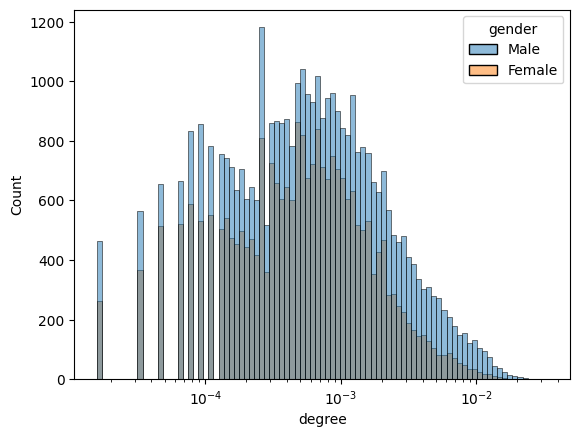

In [12]:
sns.histplot(centrality, x = 'degree', hue = 'gender', log_scale = True)
plt.show()

C:\Users\norem\AppData\Local\Temp\ipykernel_3056\3178715819.py:2: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim((10 ** -11), 0)


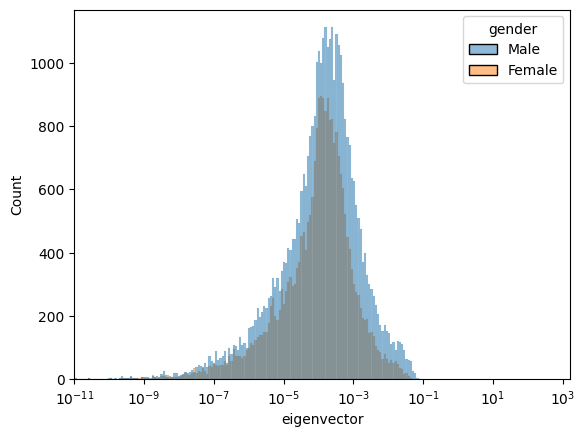

In [13]:
sns.histplot(centrality, x = 'eigenvector', hue = 'gender', log_scale = True)
plt.xlim((10 ** -11), 0)
plt.show()